# 06 - Latent Regime Inference

This notebook demonstrates the **new latent regime inference approach**.

## Key Concept

**We do NOT try to predict the real macro cycle.** Instead, we infer a latent market state that explains:
- Why the benchmark rotates between algorithm families
- What conditions favor which types of strategies

## Pipeline:
1. **Activity Masks** - Handle inactive algorithms properly (no 9999999)
2. **Algorithm Families** - Cluster algorithms by behavioral features
3. **Temporal Features** - Build aggregated features at common timestamps
4. **Regime Inference** - HMM or fuzzy scorecard
5. **Conditional Analysis** - P(family selected | regime)

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# New latent regime inference module
from src.analysis.latent_regime_inference import (
    LatentRegimeInference,
    InferenceMethod,
)

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

DATA_PATH = Path('../data')
PROCESSED = DATA_PATH / 'processed'

print("Latent Regime Inference module loaded successfully!")

Latent Regime Inference module loaded successfully!


## 1. Load Data

In [2]:
# Load algorithm returns and benchmark data
algo_returns = pd.read_parquet(PROCESSED / 'algo_returns.parquet')
benchmark_weights = pd.read_parquet(PROCESSED / 'benchmark_weights.parquet')

# Fix timezone mismatch: normalize both to timezone-naive
if algo_returns.index.tz is not None:
    algo_returns.index = algo_returns.index.tz_localize(None)
if benchmark_weights.index.tz is not None:
    benchmark_weights.index = benchmark_weights.index.tz_localize(None)

# Align indices and columns
common_cols = algo_returns.columns.intersection(benchmark_weights.columns)
common_idx = algo_returns.index.intersection(benchmark_weights.index)

algo_returns_aligned = algo_returns.loc[common_idx, common_cols]
benchmark_weights_aligned = benchmark_weights.loc[common_idx, common_cols]

# Calculate benchmark returns from weights and algo returns
benchmark_returns = (algo_returns_aligned * benchmark_weights_aligned).sum(axis=1)

print(f"Algorithms: {algo_returns.shape[1]}")
print(f"Common algorithms with benchmark: {len(common_cols)}")
print(f"Date range: {algo_returns.index.min()} to {algo_returns.index.max()}")
print(f"Total days: {len(algo_returns)}")
print(f"Aligned days: {len(common_idx)}")
print(f"Benchmark return mean: {benchmark_returns.mean():.4%}")

Algorithms: 271
Common algorithms with benchmark: 271
Date range: 2020-06-02 00:00:00 to 2024-12-30 00:00:00
Total days: 1430
Aligned days: 1429
Benchmark return mean: 0.0120%


## 2. Build Activity Mask

**IMPORTANT**: We do NOT use placeholder values like 9999999 for inactive algorithms.
Instead, we maintain explicit boolean masks.

In [3]:
# Initialize the inference engine
inference = LatentRegimeInference(n_regimes=4)

# Build activity mask
mask = inference.build_activity_mask(algo_returns)

print(f"Activity Mask shape: {mask.is_active.shape}")
print(f"\nActive algorithms per day:")
print(f"  Min: {mask.is_active.sum(axis=1).min()}")
print(f"  Max: {mask.is_active.sum(axis=1).max()}")
print(f"  Mean: {mask.is_active.sum(axis=1).mean():.1f}")

Activity Mask shape: (1430, 271)

Active algorithms per day:
  Min: 38
  Max: 189
  Mean: 110.2


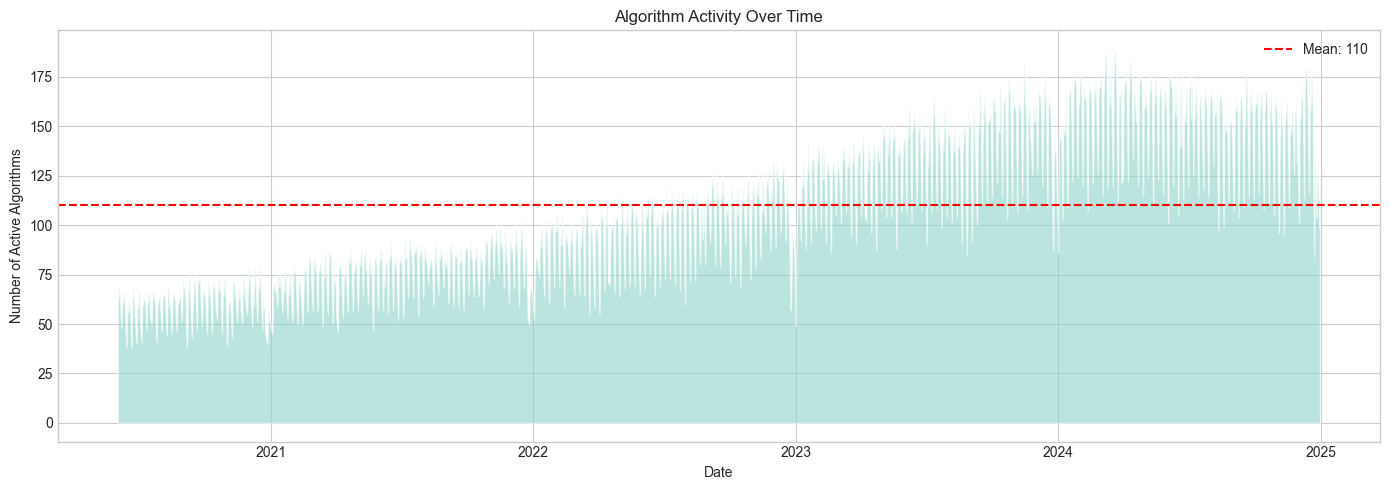

In [4]:
# Visualize activity over time
fig, ax = plt.subplots(figsize=(14, 5))

n_active = mask.is_active.sum(axis=1)
ax.fill_between(n_active.index, 0, n_active.values, alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Active Algorithms')
ax.set_title('Algorithm Activity Over Time')
ax.axhline(n_active.mean(), color='red', linestyle='--', label=f'Mean: {n_active.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

## 2.1 Impact of Active Algorithms on Equity and Risk

Analyze how the number of active algorithms relates to:
- Total equity invested (exposure)
- Volatility and risk
- Benchmark performance

In [5]:
# Analyze relationship between number of active algorithms and risk/equity

# Number of active algorithms per day
n_active = mask.is_active.sum(axis=1)

# Total exposure (sum of absolute weights from benchmark)
total_exposure = benchmark_weights_aligned.abs().sum(axis=1)

# Benchmark rolling volatility (21-day)
rolling_vol = benchmark_returns.rolling(21).std() * np.sqrt(252)

# Benchmark rolling drawdown
equity_curve = (1 + benchmark_returns).cumprod()
rolling_max = equity_curve.cummax()
drawdown = (equity_curve - rolling_max) / rolling_max

# Align all series to common index
analysis_df = pd.DataFrame({
    'n_active': n_active,
    'total_exposure': total_exposure,
    'returns': benchmark_returns,
    'rolling_vol': rolling_vol,
    'drawdown': drawdown,
    'equity': equity_curve
}).dropna()

print(f"Analysis period: {analysis_df.index.min()} to {analysis_df.index.max()}")
print(f"N observations: {len(analysis_df)}")

# Correlation matrix
corr_cols = ['n_active', 'total_exposure', 'returns', 'rolling_vol', 'drawdown']
print("\nCorrelation Matrix:")
print(analysis_df[corr_cols].corr().round(3))

Analysis period: 2020-06-26 00:00:00 to 2024-12-30 00:00:00
N observations: 1409

Correlation Matrix:
                n_active  total_exposure  returns  rolling_vol  drawdown
n_active           1.000          -0.037    0.050       -0.207     0.379
total_exposure    -0.037           1.000    0.026        0.013    -0.006
returns            0.050           0.026    1.000        0.011     0.169
rolling_vol       -0.207           0.013    0.011        1.000    -0.089
drawdown           0.379          -0.006    0.169       -0.089     1.000


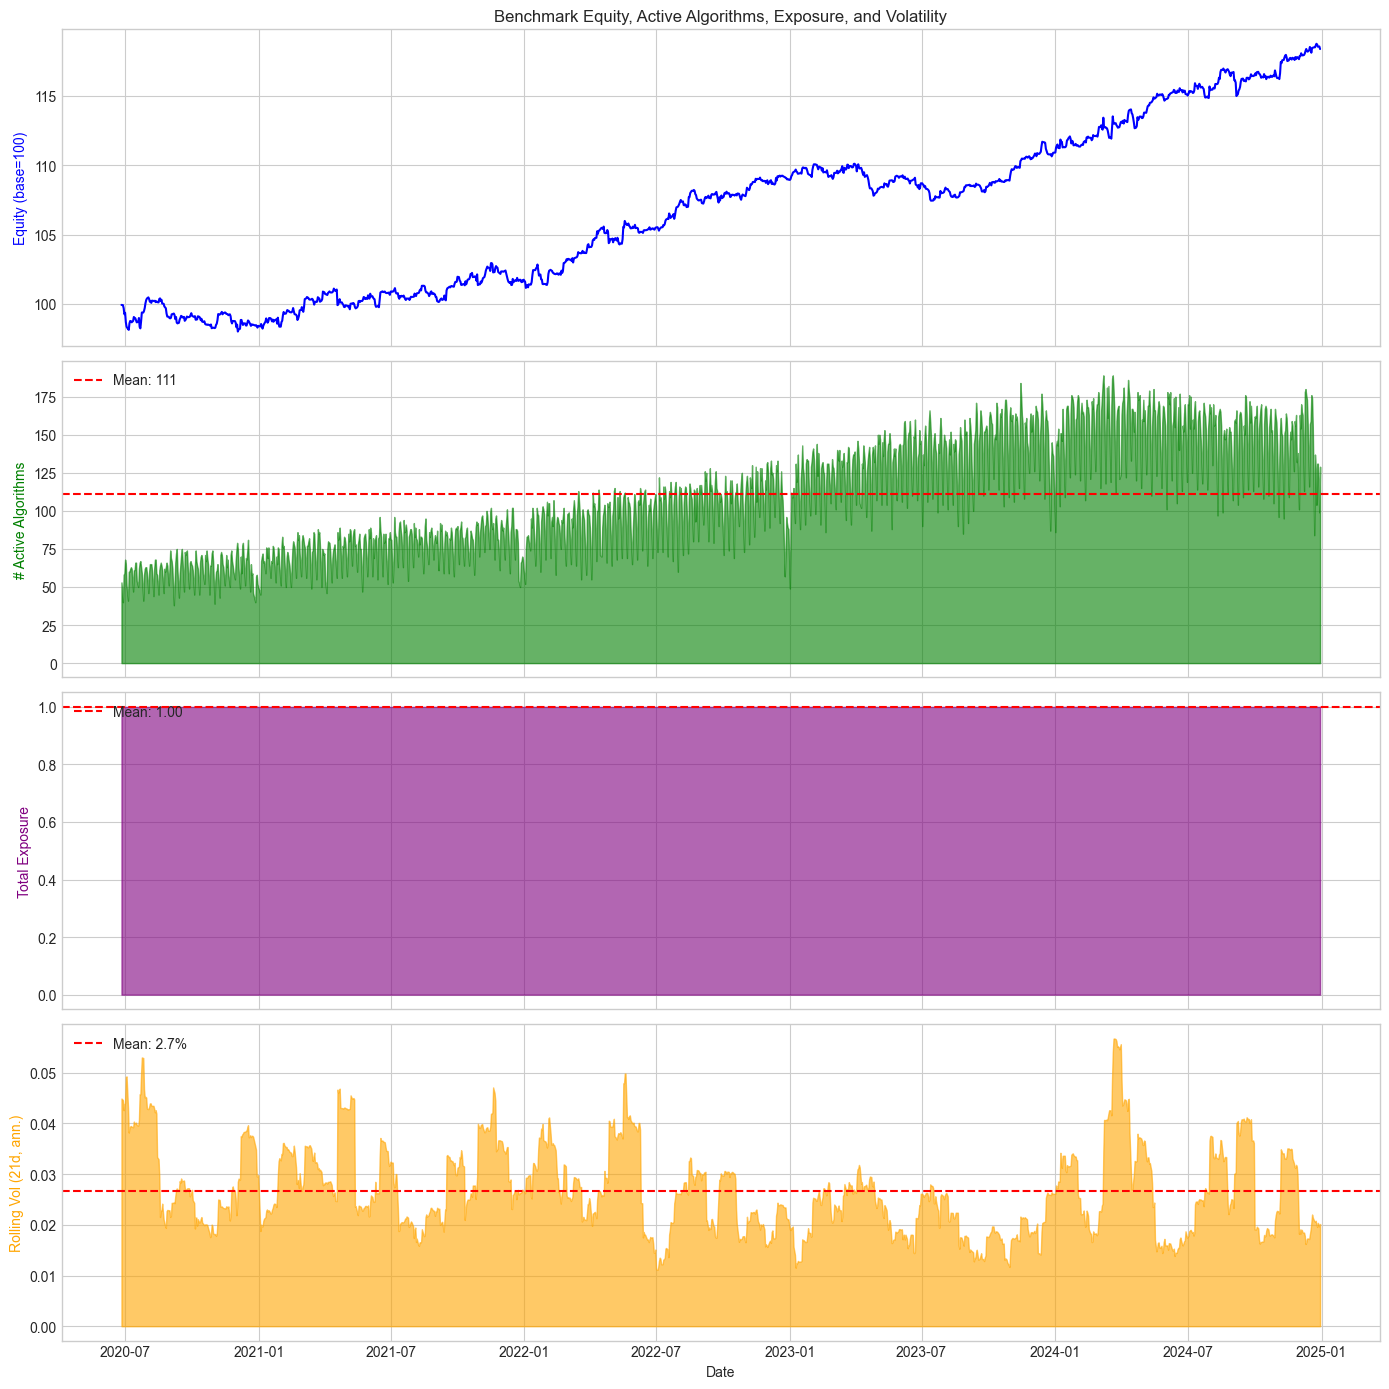

In [6]:
# Visualize: N Active Algos vs Equity and Volatility
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# 1. Equity curve
ax1 = axes[0]
ax1.plot(analysis_df.index, analysis_df['equity'] * 100, 'b-', linewidth=1.5)
ax1.set_ylabel('Equity (base=100)', color='blue')
ax1.set_title('Benchmark Equity, Active Algorithms, Exposure, and Volatility')

# 2. Number of active algorithms
ax2 = axes[1]
ax2.fill_between(analysis_df.index, 0, analysis_df['n_active'], alpha=0.6, color='green')
ax2.set_ylabel('# Active Algorithms', color='green')
ax2.axhline(analysis_df['n_active'].mean(), color='red', linestyle='--', 
            label=f"Mean: {analysis_df['n_active'].mean():.0f}")
ax2.legend(loc='upper left')

# 3. Total exposure
ax3 = axes[2]
ax3.fill_between(analysis_df.index, 0, analysis_df['total_exposure'], alpha=0.6, color='purple')
ax3.set_ylabel('Total Exposure', color='purple')
ax3.axhline(analysis_df['total_exposure'].mean(), color='red', linestyle='--',
            label=f"Mean: {analysis_df['total_exposure'].mean():.2f}")
ax3.legend(loc='upper left')

# 4. Rolling volatility
ax4 = axes[3]
ax4.fill_between(analysis_df.index, 0, analysis_df['rolling_vol'], alpha=0.6, color='orange')
ax4.set_ylabel('Rolling Vol (21d, ann.)', color='orange')
ax4.set_xlabel('Date')
ax4.axhline(analysis_df['rolling_vol'].mean(), color='red', linestyle='--',
            label=f"Mean: {analysis_df['rolling_vol'].mean():.1%}")
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

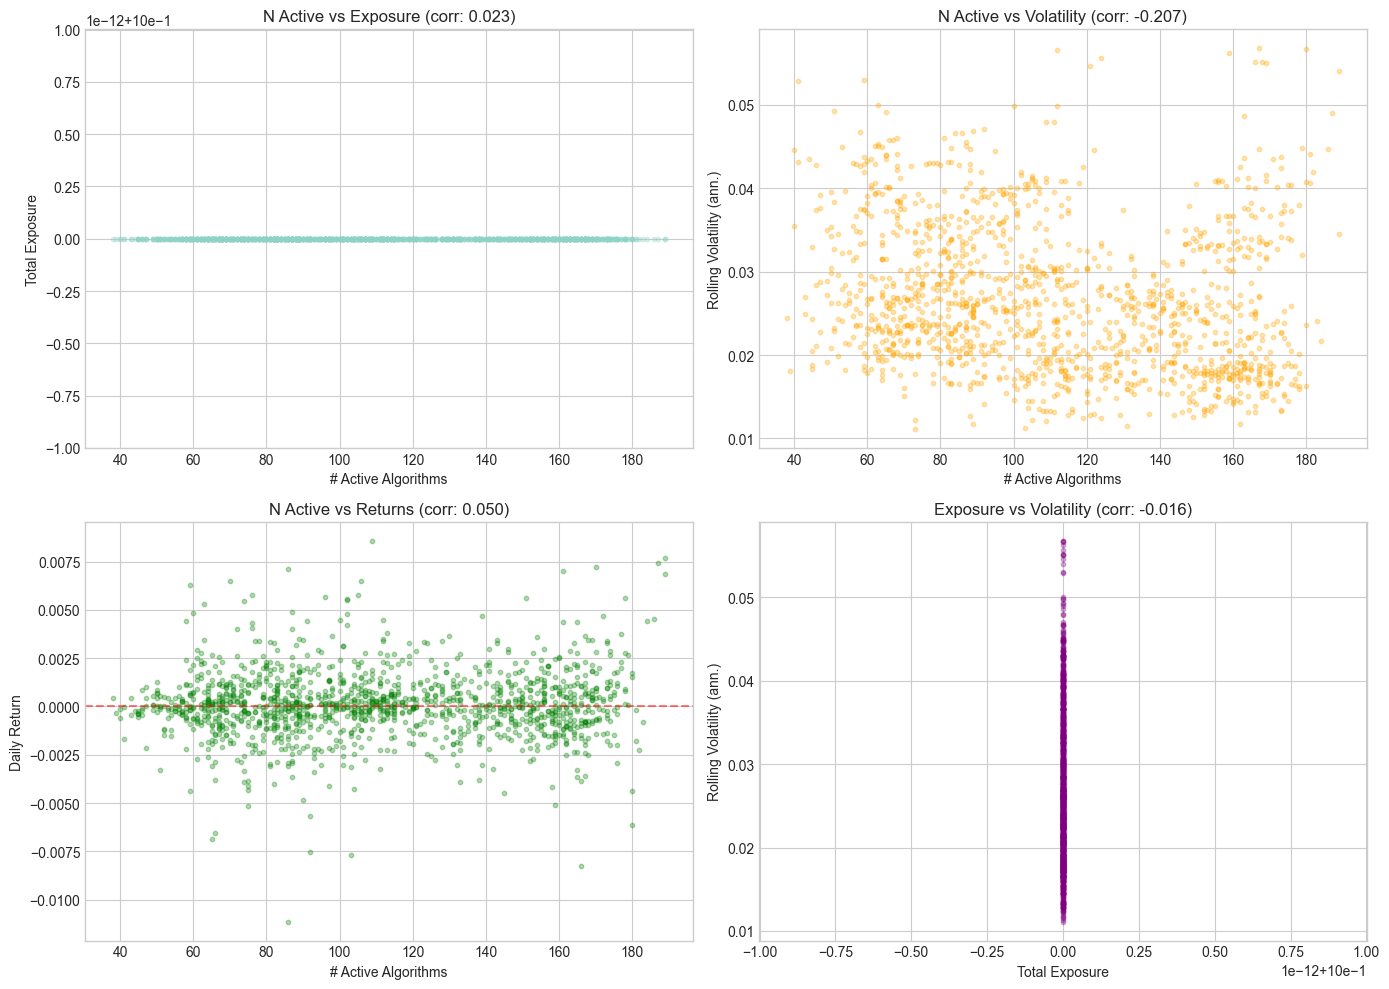

In [7]:
# Scatter plots: N Active vs Risk/Return metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. N Active vs Total Exposure
ax1 = axes[0, 0]
ax1.scatter(analysis_df['n_active'], analysis_df['total_exposure'], alpha=0.3, s=10)
ax1.set_xlabel('# Active Algorithms')
ax1.set_ylabel('Total Exposure')
ax1.set_title(f"N Active vs Exposure (corr: {analysis_df['n_active'].corr(analysis_df['total_exposure']):.3f})")

# 2. N Active vs Rolling Volatility
ax2 = axes[0, 1]
ax2.scatter(analysis_df['n_active'], analysis_df['rolling_vol'], alpha=0.3, s=10, c='orange')
ax2.set_xlabel('# Active Algorithms')
ax2.set_ylabel('Rolling Volatility (ann.)')
ax2.set_title(f"N Active vs Volatility (corr: {analysis_df['n_active'].corr(analysis_df['rolling_vol']):.3f})")

# 3. N Active vs Daily Returns
ax3 = axes[1, 0]
ax3.scatter(analysis_df['n_active'], analysis_df['returns'], alpha=0.3, s=10, c='green')
ax3.axhline(0, color='red', linestyle='--', alpha=0.5)
ax3.set_xlabel('# Active Algorithms')
ax3.set_ylabel('Daily Return')
ax3.set_title(f"N Active vs Returns (corr: {analysis_df['n_active'].corr(analysis_df['returns']):.3f})")

# 4. Total Exposure vs Rolling Volatility
ax4 = axes[1, 1]
ax4.scatter(analysis_df['total_exposure'], analysis_df['rolling_vol'], alpha=0.3, s=10, c='purple')
ax4.set_xlabel('Total Exposure')
ax4.set_ylabel('Rolling Volatility (ann.)')
ax4.set_title(f"Exposure vs Volatility (corr: {analysis_df['total_exposure'].corr(analysis_df['rolling_vol']):.3f})")

plt.tight_layout()
plt.show()

Performance Metrics by Number of Active Algorithms:
                 n_active_mean  n_active_count  total_exposure_mean  returns_ann  rolling_vol_mean  drawdown_min  sharpe_approx
n_active_bucket                                                                                                                
Very Low               62.4315             292                  1.0       0.0000            0.0294       -0.0296           0.00
Low                    84.4412             272                  1.0      -0.0252            0.0285       -0.0308          -0.79
Medium                106.5368             285                  1.0       0.0756            0.0266       -0.0241           2.80
High                  137.6584             281                  1.0       0.0252            0.0232       -0.0242           1.13
Very High             165.2115             279                  1.0       0.0504            0.0256       -0.0233           1.59


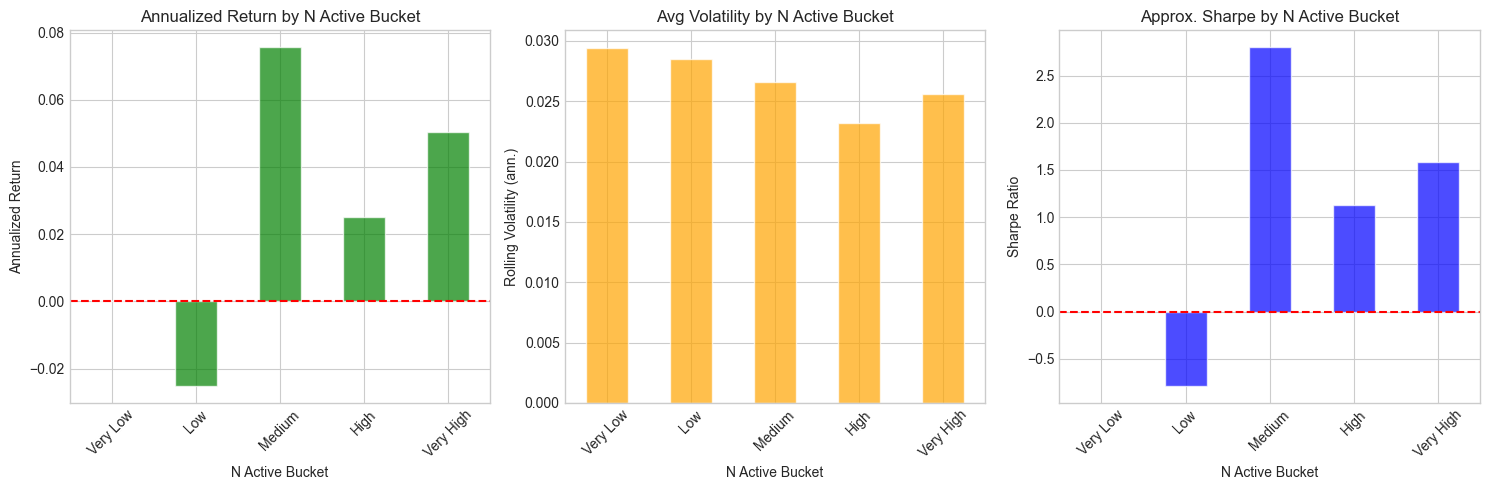

In [8]:
# Segmented analysis: Performance metrics by N Active buckets
# Create buckets based on number of active algorithms
analysis_df['n_active_bucket'] = pd.qcut(analysis_df['n_active'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Calculate metrics per bucket
bucket_stats = analysis_df.groupby('n_active_bucket').agg({
    'n_active': ['mean', 'min', 'max', 'count'],
    'total_exposure': 'mean',
    'returns': ['mean', 'std'],
    'rolling_vol': 'mean',
    'drawdown': 'min',  # worst drawdown
}).round(4)

# Flatten column names
bucket_stats.columns = ['_'.join(col).strip() for col in bucket_stats.columns]

# Calculate Sharpe-like ratio per bucket
bucket_stats['sharpe_approx'] = (bucket_stats['returns_mean'] / bucket_stats['returns_std'] * np.sqrt(252)).round(2)

# Annualize returns
bucket_stats['returns_ann'] = (bucket_stats['returns_mean'] * 252).round(4)

print("Performance Metrics by Number of Active Algorithms:")
print("=" * 80)
display_cols = ['n_active_mean', 'n_active_count', 'total_exposure_mean', 
                'returns_ann', 'rolling_vol_mean', 'drawdown_min', 'sharpe_approx']
print(bucket_stats[display_cols].to_string())

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Annualized return by bucket
ax1 = axes[0]
bucket_stats['returns_ann'].plot(kind='bar', ax=ax1, color='green', alpha=0.7)
ax1.set_title('Annualized Return by N Active Bucket')
ax1.set_ylabel('Annualized Return')
ax1.set_xlabel('N Active Bucket')
ax1.axhline(0, color='red', linestyle='--')
plt.setp(ax1.get_xticklabels(), rotation=45)

# Volatility by bucket
ax2 = axes[1]
bucket_stats['rolling_vol_mean'].plot(kind='bar', ax=ax2, color='orange', alpha=0.7)
ax2.set_title('Avg Volatility by N Active Bucket')
ax2.set_ylabel('Rolling Volatility (ann.)')
ax2.set_xlabel('N Active Bucket')
plt.setp(ax2.get_xticklabels(), rotation=45)

# Sharpe by bucket
ax3 = axes[2]
bucket_stats['sharpe_approx'].plot(kind='bar', ax=ax3, color='blue', alpha=0.7)
ax3.set_title('Approx. Sharpe by N Active Bucket')
ax3.set_ylabel('Sharpe Ratio')
ax3.set_xlabel('N Active Bucket')
ax3.axhline(0, color='red', linestyle='--')
plt.setp(ax3.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## 3. Compute Algorithm Behavioral Features

Before clustering into families, we extract features that describe each algorithm's behavior.

In [9]:
# Compute behavioral features for each algorithm
algo_features = inference.compute_algo_behavioral_features(algo_returns, mask)

print(f"Computed features for {len(algo_features)} algorithms")
print(f"\nFeatures: {list(algo_features.columns)}")
print(f"\nFeature statistics:")
print(algo_features.describe().T[['mean', 'std', 'min', 'max']].round(4))

Computed features for 271 algorithms

Features: ['ann_return', 'ann_vol', 'sharpe', 'sortino', 'max_dd', 'skewness', 'kurtosis', 'tail_ratio', 'autocorr_1', 'autocorr_5', 'beta_universe', 'beta_drawdowns', 'sharpe_stability', 'return_stability']

Feature statistics:
                     mean      std      min       max
ann_return         0.0254   0.0350  -0.0793    0.1264
ann_vol            0.0730   0.0295   0.0034    0.1548
sharpe             0.3235   0.4235  -0.9123    1.5021
sortino            0.3044   0.4261  -0.9256    1.7305
max_dd            -0.1472   0.0837  -0.4508   -0.0051
skewness           0.1928   3.6008 -14.6917   17.0899
kurtosis          60.3957  80.0803   2.7833  514.5413
tail_ratio         1.2590   1.1340   0.0000   10.0000
autocorr_1        -0.0165   0.0891  -0.6293    0.2606
autocorr_5         0.0026   0.0695  -0.4591    0.2629
beta_universe      1.0000   0.9952  -0.9561    4.3726
beta_drawdowns     0.0313   0.0426  -0.1540    0.1484
sharpe_stability   0.9168   0.9

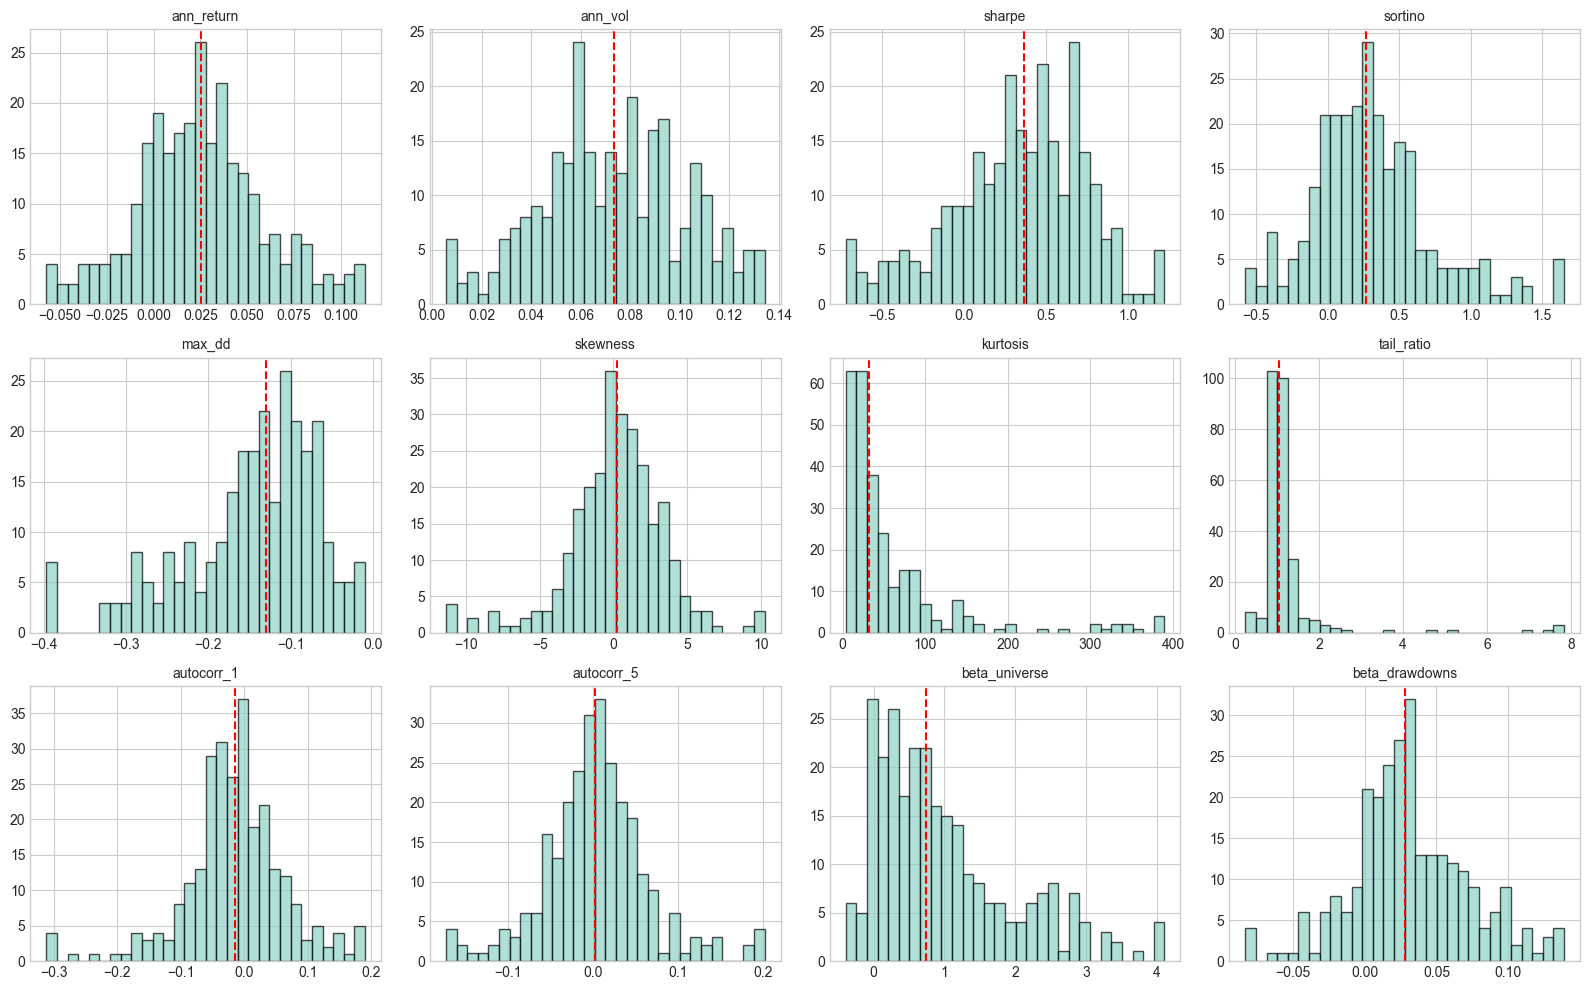

In [10]:
# Visualize feature distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(algo_features.columns[:12]):
    ax = axes[i]
    data = algo_features[col].dropna()
    # Clip for visualization
    data_clipped = data.clip(data.quantile(0.01), data.quantile(0.99))
    ax.hist(data_clipped, bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.3f}')

plt.tight_layout()
plt.show()

## 4. Assign Algorithms to Families

We cluster algorithms into behavioral families:
- **trend_following**: High autocorrelation, positive beta to trends
- **mean_reversion**: Negative autocorrelation
- **low_vol_carry**: Low volatility, stable sharpe
- **crisis_alpha**: Negative beta to drawdowns
- etc.

In [11]:
# Assign families using GMM clustering
family_labels = inference.assign_families(algo_features, n_families=6, method='gmm')

# Summary
family_counts = family_labels.value_counts().sort_index()
print("Family Distribution:")
for family_id, count in family_counts.items():
    print(f"  Family {family_id}: {count} algorithms")

Family Distribution:
  Family 0: 122 algorithms
  Family 1: 5 algorithms
  Family 2: 68 algorithms
  Family 3: 10 algorithms
  Family 4: 56 algorithms
  Family 5: 10 algorithms


In [12]:
# Analyze each family's characteristics
algo_features_with_family = algo_features.copy()
algo_features_with_family['family'] = family_labels

family_profiles = algo_features_with_family.groupby('family').mean()
print("\nFamily Profiles (mean features):")
print(family_profiles[['sharpe', 'ann_vol', 'max_dd', 'autocorr_1', 'beta_drawdowns']].round(3))


Family Profiles (mean features):
        sharpe  ann_vol  max_dd  autocorr_1  beta_drawdowns
family                                                     
0        0.581    0.085  -0.134      -0.018           0.035
1        0.511    0.057  -0.096      -0.027           0.008
2       -0.109    0.086  -0.247       0.002           0.046
3        0.015    0.011  -0.019      -0.072           0.004
4        0.286    0.046  -0.089      -0.019           0.013
5        0.555    0.060  -0.104      -0.052           0.026


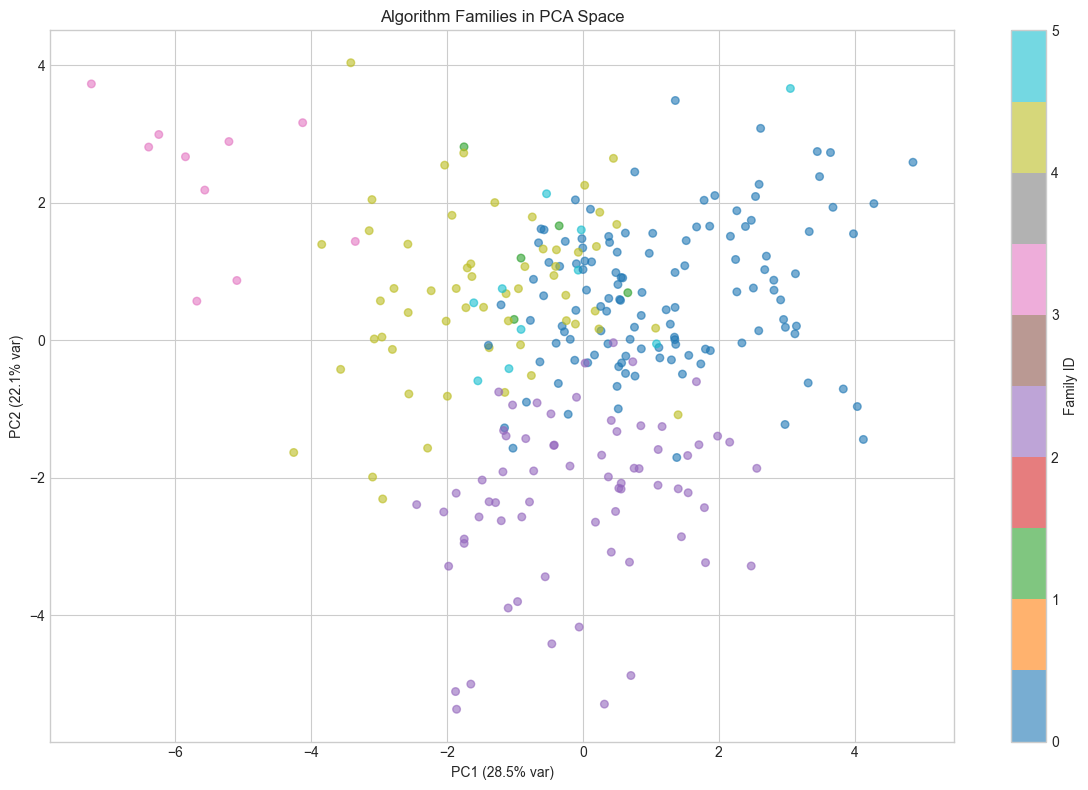

In [13]:
# Visualize families in 2D (using PCA or key features)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Prepare data
X = algo_features.replace([np.inf, -np.inf], np.nan).fillna(algo_features.median())
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=family_labels, cmap='tab10', alpha=0.6, s=30)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('Algorithm Families in PCA Space')
plt.colorbar(scatter, label='Family ID')
plt.tight_layout()
plt.show()

## 5. Build Temporal Features

Now we aggregate features over time:
- **Family aggregates**: Returns, weights, dispersion per family
- **Universe features**: Cross-sectional dispersion, correlation, breadth
- **Benchmark features**: Returns, volatility, turnover, concentration

In [14]:
# Build temporal features
family_agg, universe_feat, bench_feat = inference.build_temporal_features(
    algo_returns, benchmark_weights, benchmark_returns, family_labels, mask
)

print("Temporal Features Built:")
print(f"  Family aggregates: {family_agg.returns.shape}")
print(f"  Universe features: {len(universe_feat.cross_sectional_dispersion)} timestamps")
print(f"  Benchmark features: {len(bench_feat.returns)} timestamps")

Temporal Features Built:
  Family aggregates: (1430, 6)
  Universe features: 1430 timestamps
  Benchmark features: 1429 timestamps


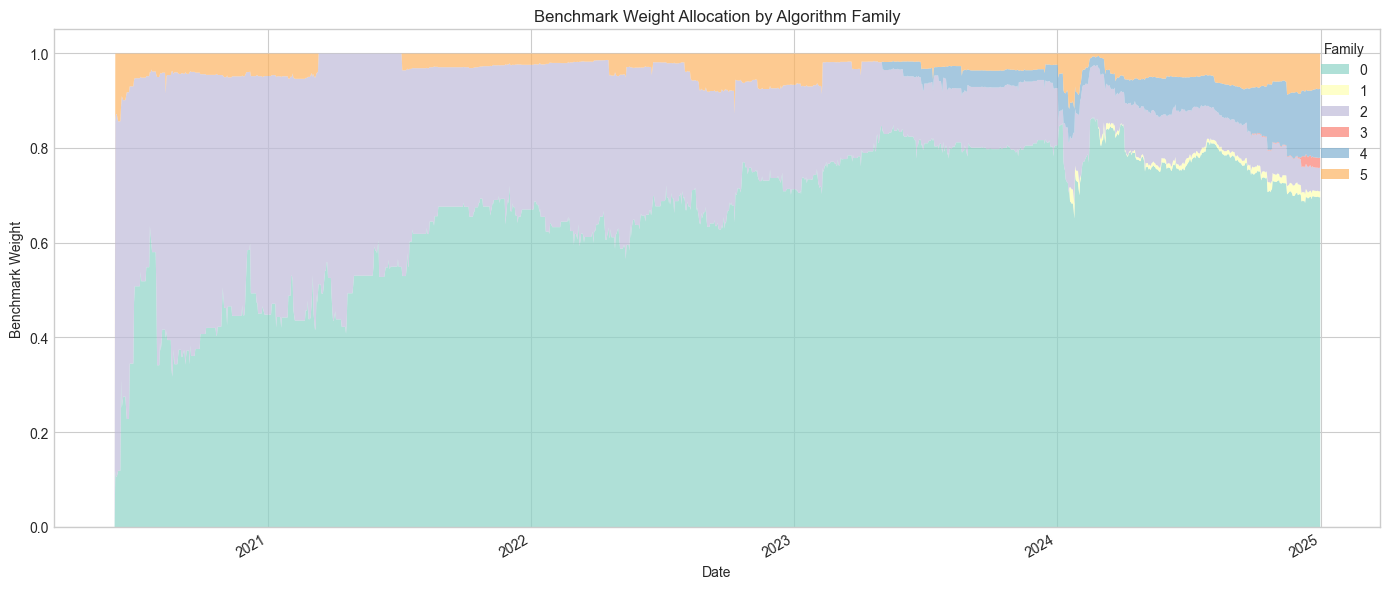

In [15]:
# Visualize family weights over time
fig, ax = plt.subplots(figsize=(14, 6))

# Stack plot of family weights
family_weights = family_agg.weights.fillna(0)
family_weights.plot.area(ax=ax, alpha=0.7, linewidth=0)

ax.set_xlabel('Date')
ax.set_ylabel('Benchmark Weight')
ax.set_title('Benchmark Weight Allocation by Algorithm Family')
ax.legend(title='Family', loc='upper right')
plt.tight_layout()
plt.show()

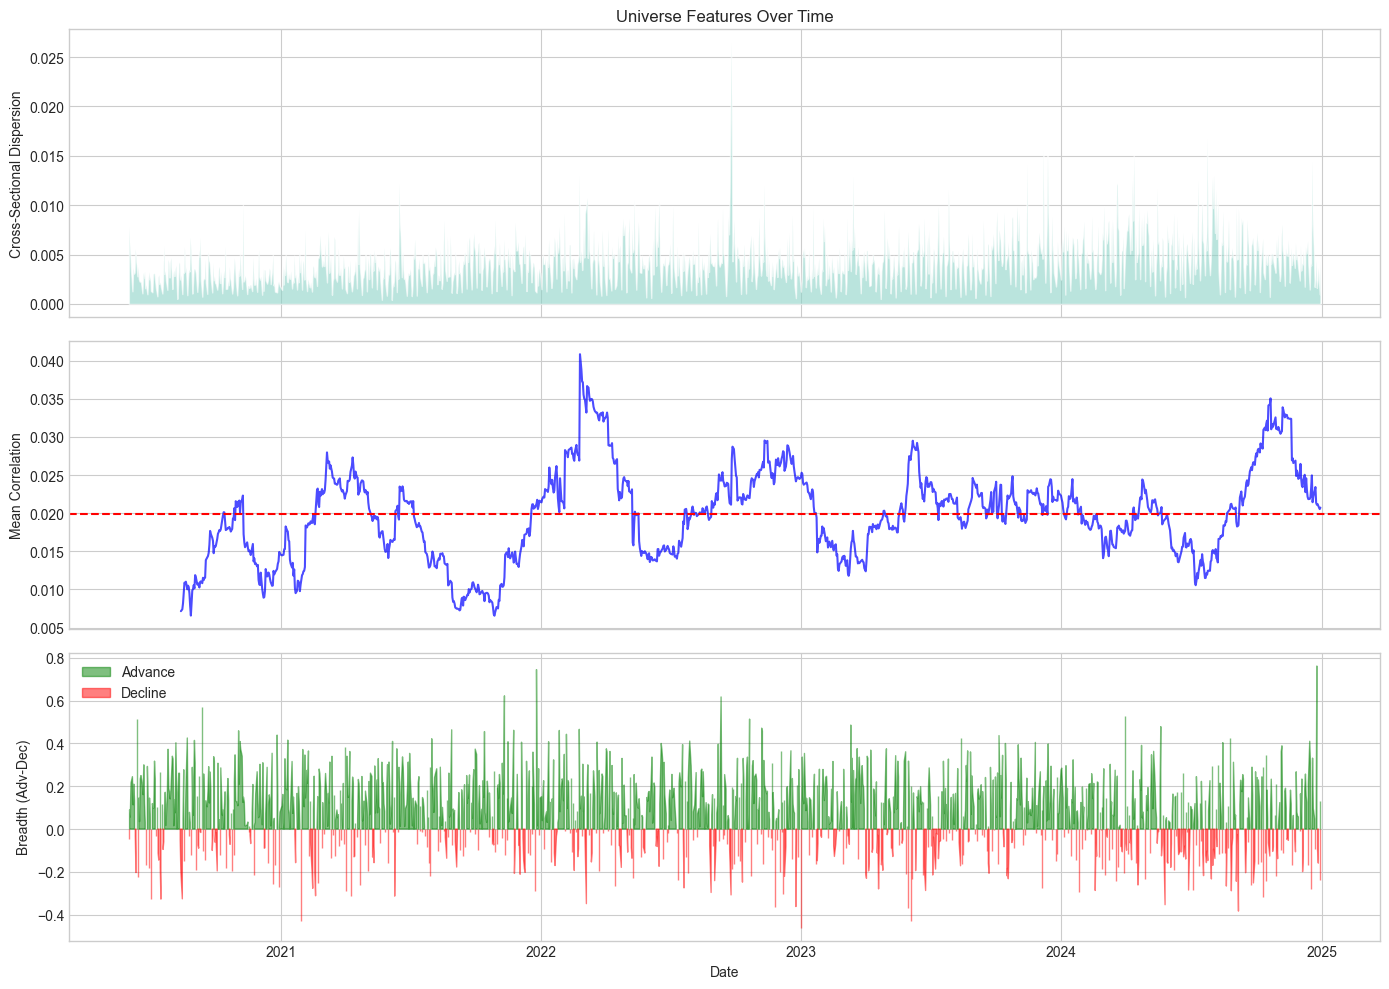

In [16]:
# Visualize universe features
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Cross-sectional dispersion
ax1 = axes[0]
ax1.fill_between(universe_feat.cross_sectional_dispersion.index, 
                 0, universe_feat.cross_sectional_dispersion.values, alpha=0.6)
ax1.set_ylabel('Cross-Sectional Dispersion')
ax1.set_title('Universe Features Over Time')

# Mean correlation
ax2 = axes[1]
corr = universe_feat.mean_correlation.dropna()
ax2.plot(corr.index, corr.values, 'b-', alpha=0.7)
ax2.axhline(corr.median(), color='red', linestyle='--')
ax2.set_ylabel('Mean Correlation')

# Breadth
ax3 = axes[2]
breadth = universe_feat.breadth_advance_decline
ax3.fill_between(breadth.index, 0, breadth.values, 
                 where=breadth >= 0, color='green', alpha=0.5, label='Advance')
ax3.fill_between(breadth.index, 0, breadth.values, 
                 where=breadth < 0, color='red', alpha=0.5, label='Decline')
ax3.set_ylabel('Breadth (Adv-Dec)')
ax3.set_xlabel('Date')
ax3.legend()

plt.tight_layout()
plt.show()

## 6. Infer Latent Regimes

Now we infer latent market regimes using the aggregated features.

In [17]:
# Try fuzzy scorecard method first (more interpretable)
result_fuzzy = inference.infer_regimes(
    family_agg, universe_feat, bench_feat,
    method=InferenceMethod.FUZZY_SCORECARD
)

print("Fuzzy Scorecard Results:")
print(f"  Unique regimes: {result_fuzzy.regime_labels.nunique()}")
print(f"\nRegime Distribution:")
for regime_id, name in result_fuzzy.regime_names.items():
    count = (result_fuzzy.regime_labels == regime_id).sum()
    pct = count / len(result_fuzzy.regime_labels) * 100
    print(f"  {regime_id} ({name}): {count} days ({pct:.1f}%)")

Fuzzy Scorecard Results:
  Unique regimes: 3

Regime Distribution:
  0.0 (slowdown): 21 days (1.5%)
  3.0 (expansion): 1314 days (92.0%)
  1.0 (recovery): 94 days (6.6%)


In [18]:
# Try HMM method (if hmmlearn is installed)
try:
    result_hmm = inference.infer_regimes(
        family_agg, universe_feat, bench_feat,
        method=InferenceMethod.HMM
    )
    
    print("HMM Results:")
    print(f"  Log-likelihood: {result_hmm.log_likelihood:.2f}")
    print(f"  BIC: {result_hmm.bic:.2f}")
    print(f"\nRegime Distribution:")
    for regime_id, name in result_hmm.regime_names.items():
        count = (result_hmm.regime_labels == regime_id).sum()
        pct = count / len(result_hmm.regime_labels) * 100
        print(f"  {regime_id} ({name}): {count} days ({pct:.1f}%)")
    
    # Use HMM result for downstream analysis
    result = result_hmm
    print("\n-> Using HMM result for analysis")
except Exception as e:
    print(f"HMM failed: {e}")
    print("-> Using Fuzzy result for analysis")
    result = result_fuzzy

Model is not converging.  Current: 964.4202913322684 is not greater than 10590.70876926174. Delta is -9626.288477929473


HMM Results:
  Log-likelihood: 1679.60
  BIC: 4748.25

Regime Distribution:
  0 (slowdown): 203 days (14.2%)
  3 (expansion): 56 days (3.9%)
  2 (recovery): 122 days (8.5%)
  1 (recession): 1048 days (73.3%)

-> Using HMM result for analysis


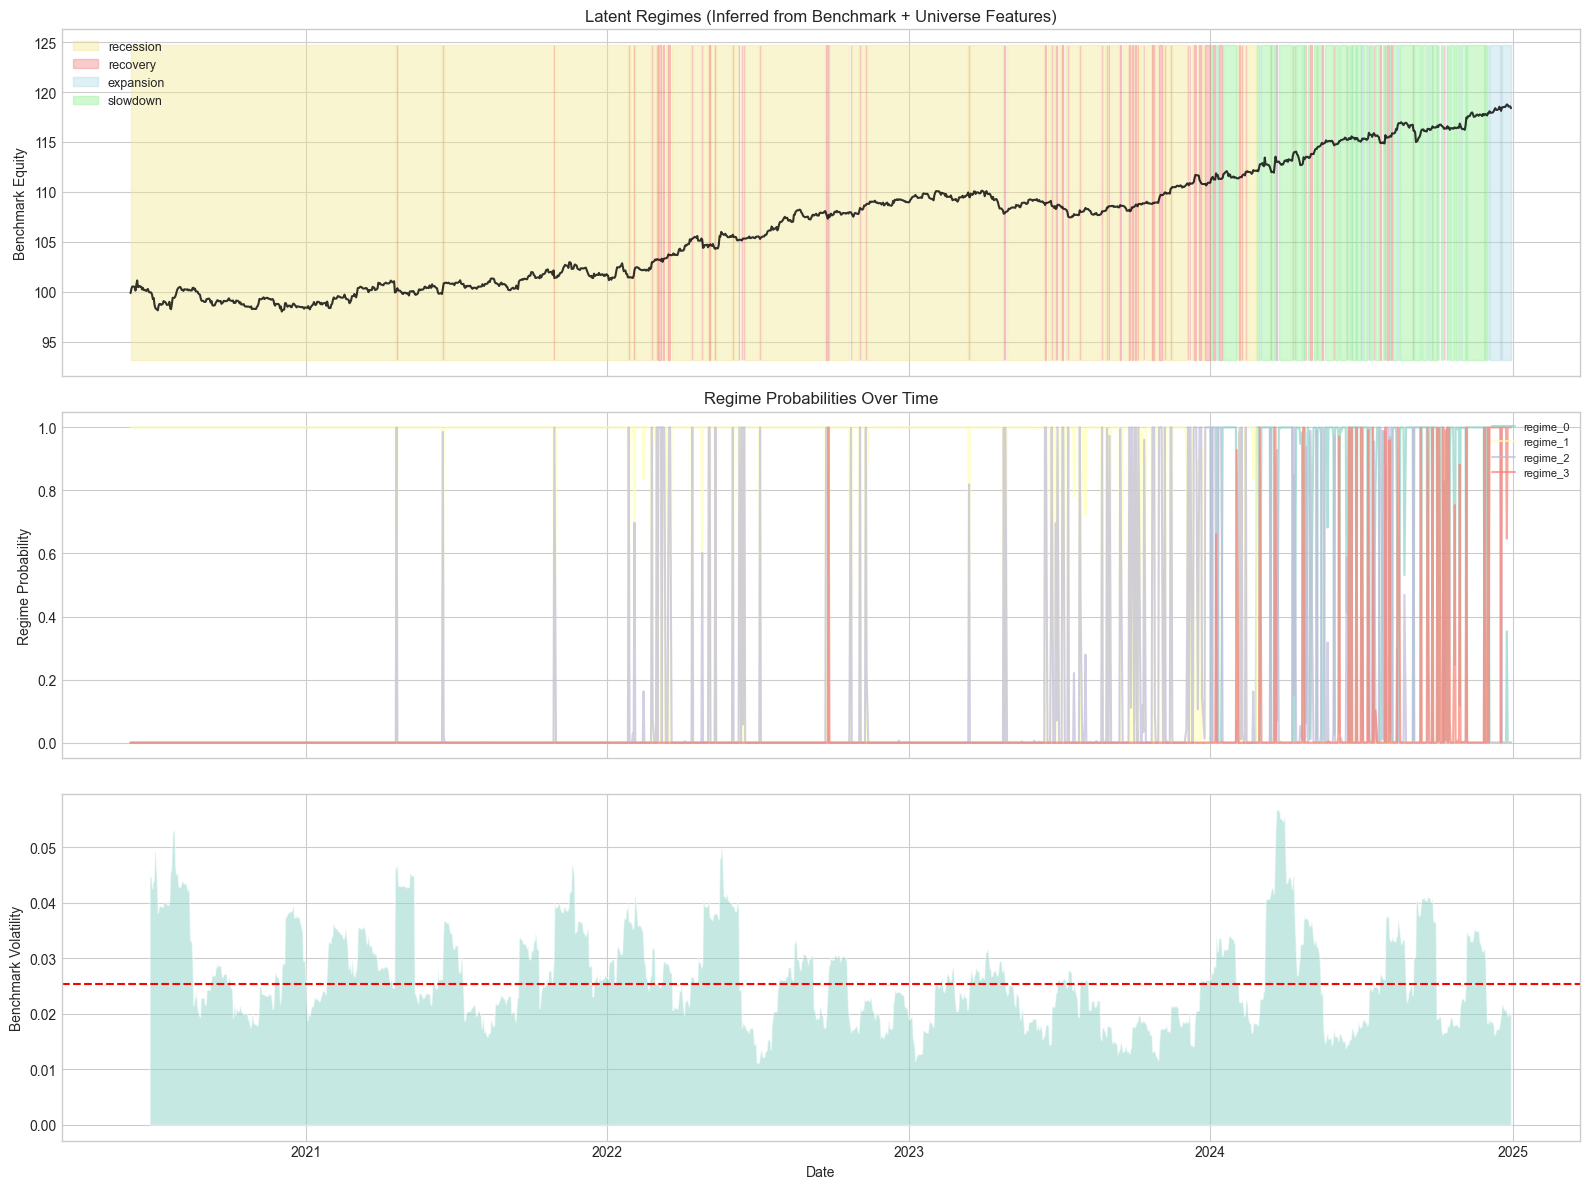

In [19]:
# Visualize regimes over time
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Benchmark equity with regime coloring
ax1 = axes[0]
equity = (1 + benchmark_returns).cumprod() * 100
ax1.plot(equity.index, equity.values, 'k-', linewidth=1.5, alpha=0.8)

regime_colors = {0: 'lightgreen', 1: 'khaki', 2: 'lightcoral', 3: 'lightblue'}

for regime_id in result.regime_labels.unique():
    mask_regime = result.regime_labels == regime_id
    color = regime_colors.get(regime_id, 'gray')
    name = result.regime_names.get(regime_id, f'regime_{regime_id}')
    ax1.fill_between(
        equity.index, equity.min() * 0.95, equity.max() * 1.05,
        where=mask_regime.reindex(equity.index).fillna(False),
        alpha=0.4, color=color, label=name
    )

ax1.set_ylabel('Benchmark Equity')
ax1.set_title('Latent Regimes (Inferred from Benchmark + Universe Features)')
ax1.legend(loc='upper left', fontsize=9)

# Regime probabilities
ax2 = axes[1]
result.regime_probabilities.plot(ax=ax2, alpha=0.7)
ax2.set_ylabel('Regime Probability')
ax2.set_title('Regime Probabilities Over Time')
ax2.legend(loc='upper right', fontsize=8)

# Benchmark volatility
ax3 = axes[2]
ax3.fill_between(bench_feat.volatility.index, 0, bench_feat.volatility.values, alpha=0.5)
ax3.axhline(bench_feat.volatility.median(), color='red', linestyle='--')
ax3.set_ylabel('Benchmark Volatility')
ax3.set_xlabel('Date')

plt.tight_layout()
plt.show()

## 7. Analyze Benchmark Conditional on Regime

**Key Question**: Given the inferred regime, which algorithm families does the benchmark favor?

In [20]:
# Conditional analysis
conditional = inference.analyze_benchmark_conditional(
    benchmark_weights, family_labels, result.regime_labels, algo_returns
)

print("Benchmark Conditional Analysis Complete!")
print(f"\nFamily weights by regime available: {len(conditional.family_weights_by_regime)} regimes")

Benchmark Conditional Analysis Complete!

Family weights by regime available: 4 regimes


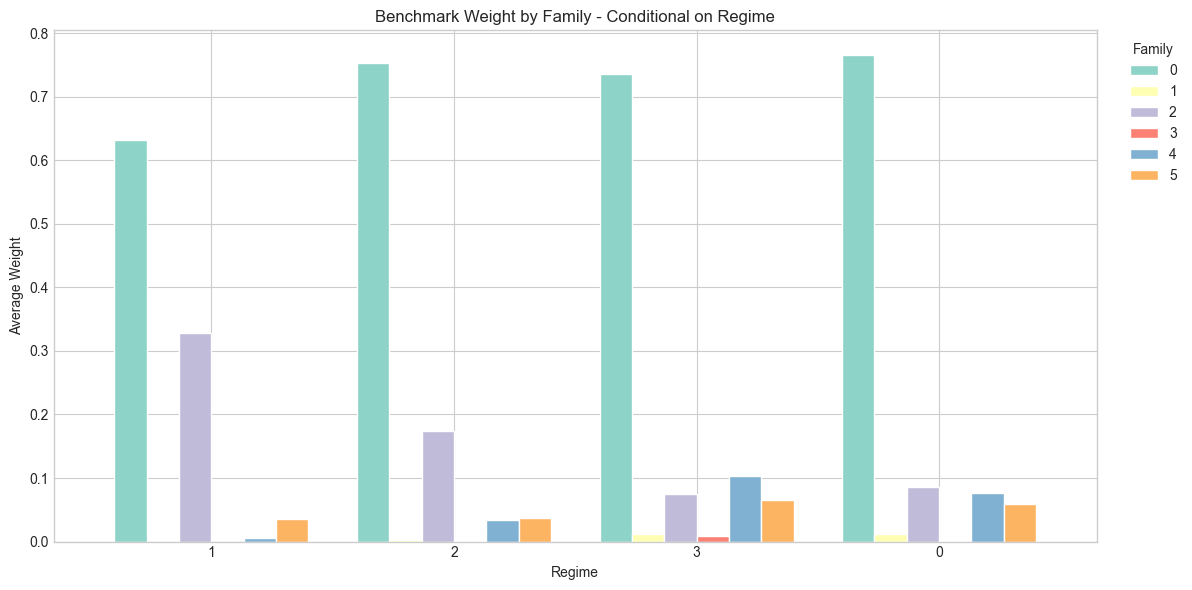


Family Weights by Regime:
            0      1      2      3      4      5
Regime                                          
1       0.632  0.000  0.328  0.000  0.005  0.035
2       0.753  0.002  0.174  0.000  0.034  0.037
3       0.736  0.012  0.075  0.009  0.104  0.066
0       0.766  0.011  0.086  0.000  0.077  0.059


In [21]:
# Visualize family weights by regime
weights_df = pd.DataFrame(conditional.family_weights_by_regime).T
weights_df.index.name = 'Regime'

fig, ax = plt.subplots(figsize=(12, 6))
weights_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_xlabel('Regime')
ax.set_ylabel('Average Weight')
ax.set_title('Benchmark Weight by Family - Conditional on Regime')
ax.legend(title='Family', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nFamily Weights by Regime:")
print(weights_df.round(3))

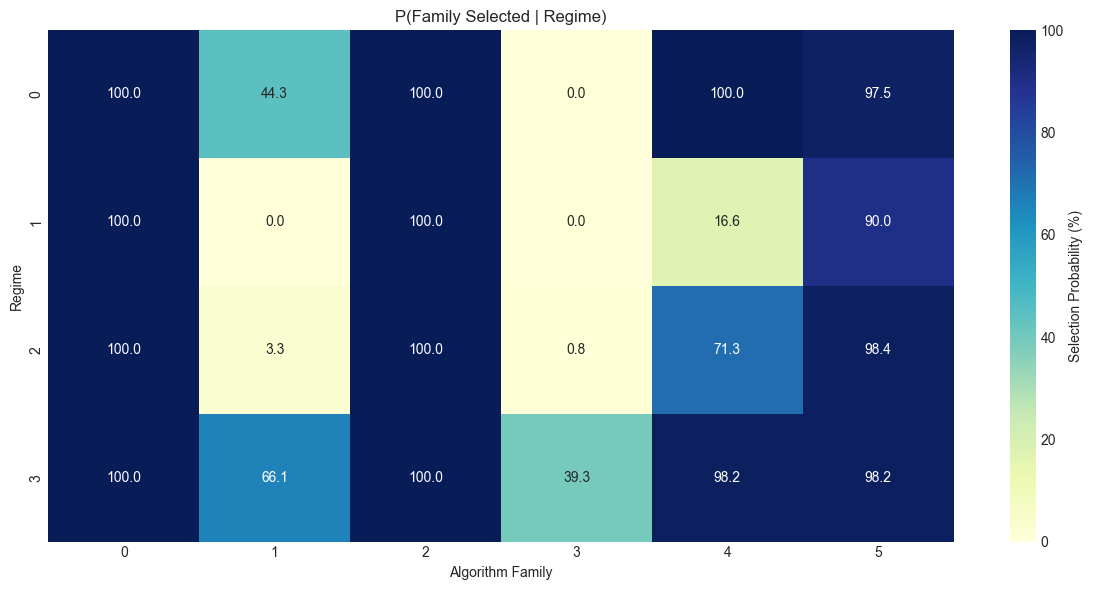

In [22]:
# Selection probability heatmap
fig, ax = plt.subplots(figsize=(12, 6))

selection_prob = conditional.selection_probability
sns.heatmap(
    selection_prob * 100, 
    annot=True, fmt='.1f', 
    cmap='YlGnBu',
    cbar_kws={'label': 'Selection Probability (%)'},
    ax=ax
)
ax.set_title('P(Family Selected | Regime)')
ax.set_xlabel('Algorithm Family')
ax.set_ylabel('Regime')
plt.tight_layout()
plt.show()

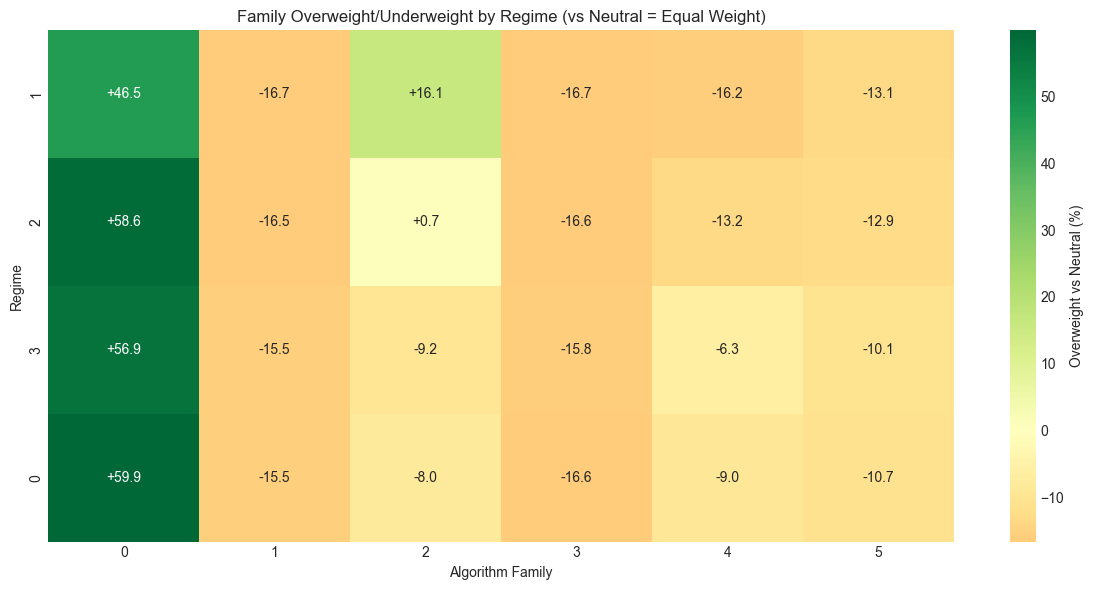

In [23]:
# Overweight analysis
overweight_df = pd.DataFrame(conditional.family_overweight_by_regime).T

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    overweight_df * 100, 
    annot=True, fmt='+.1f', 
    cmap='RdYlGn', center=0,
    cbar_kws={'label': 'Overweight vs Neutral (%)'},
    ax=ax
)
ax.set_title('Family Overweight/Underweight by Regime (vs Neutral = Equal Weight)')
ax.set_xlabel('Algorithm Family')
ax.set_ylabel('Regime')
plt.tight_layout()
plt.show()

## 8. Generate Full Report

In [24]:
# Generate comprehensive report
report = inference.generate_report(result, conditional)
print(report)


LATENT REGIME INFERENCE REPORT
═══════════════════════════════════════════════════════════════════

OBJETIVO
────────────────────────────────────────────────────────────────────
Inferir un estado latente del mercado que explique el patron de
seleccion y rotacion del benchmark entre familias de algoritmos.
(NO intentamos predecir el ciclo macro real)

REGIMENES DETECTADOS
────────────────────────────────────────────────────────────────────

0. SLOWDOWN
   Dias: 203 (14.2% del tiempo)
   Vol benchmark: 2.91%
   Retorno benchmark: -0.0001

3. EXPANSION
   Dias: 56 (3.9% del tiempo)
   Vol benchmark: 2.41%
   Retorno benchmark: 0.0016

2. RECOVERY
   Dias: 122 (8.5% del tiempo)
   Vol benchmark: 2.56%
   Retorno benchmark: 0.0002

1. RECESSION
   Dias: 1048 (73.3% del tiempo)
   Vol benchmark: 2.68%
   Retorno benchmark: 0.0001

COMPORTAMIENTO DEL BENCHMARK POR REGIMEN
────────────────────────────────────────────────────────────────────

Regimen 1:
   0: 63.2% (vs neutro: +46.5%)
   2: 32

## 9. Transition Matrix Analysis

How do regimes transition from one to another?

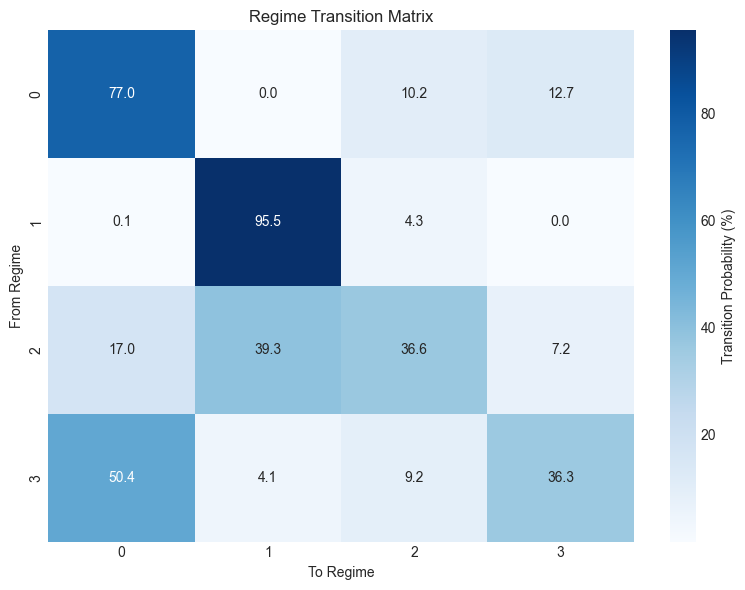


Transition Matrix:
       0      1      2      3
0  0.770  0.000  0.102  0.127
1  0.001  0.955  0.043  0.000
2  0.170  0.393  0.366  0.072
3  0.504  0.041  0.092  0.363


In [25]:
# Transition matrix visualization
if not result.transition_matrix.empty:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        result.transition_matrix * 100,
        annot=True, fmt='.1f',
        cmap='Blues',
        cbar_kws={'label': 'Transition Probability (%)'},
        ax=ax
    )
    ax.set_title('Regime Transition Matrix')
    ax.set_xlabel('To Regime')
    ax.set_ylabel('From Regime')
    plt.tight_layout()
    plt.show()
    
    print("\nTransition Matrix:")
    print(result.transition_matrix.round(3))
else:
    print("Transition matrix not available for this method")

## 10. Save Results

In [26]:
# Save regime labels
result.regime_labels.to_frame('regime').to_parquet(PROCESSED / 'latent_regime_labels.parquet')

# Save family labels
family_labels.to_frame('family').to_parquet(PROCESSED / 'algo_family_labels.parquet')

# Save regime probabilities
result.regime_probabilities.to_parquet(PROCESSED / 'latent_regime_probs.parquet')

# Save selection probabilities
conditional.selection_probability.to_parquet(PROCESSED / 'family_selection_by_regime.parquet')

print("Results saved to data/processed/:")
print("  - latent_regime_labels.parquet")
print("  - algo_family_labels.parquet")
print("  - latent_regime_probs.parquet")
print("  - family_selection_by_regime.parquet")

Results saved to data/processed/:
  - latent_regime_labels.parquet
  - algo_family_labels.parquet
  - latent_regime_probs.parquet
  - family_selection_by_regime.parquet


## Summary

### Key Insights

1. **Latent Regimes**: We identified regimes based on what explains benchmark behavior, NOT based on predicting macro cycles.

2. **Algorithm Families**: Algorithms were clustered into behavioral families (trend, mean-reversion, low-vol, crisis-alpha, etc.).

3. **Conditional Selection**: We can now answer: "Given regime X, what's the probability the benchmark selects family Y?"

4. **Regime Transitions**: The transition matrix shows how regimes evolve over time.

### Implications for Meta-Allocator

- The RL agent can use inferred regime probabilities as part of its state
- Conditional selection probabilities provide a baseline policy to beat
- Family-level analysis reduces the dimensionality from 14,000+ algos to ~6-8 families